# Data Management and Training Logistics

## Preparing the data: recap

The essential element of all machine learning projects is **the data**. Because of that, it is always necessary to perform an Exploratory Data Analysis (EDA) first. The objective is to understand the data we are working with. Is it clean, or are there samples with errors and missing values? Are there patterns we can see by just correlating a couple of variables? What about three? One of the core principles of machine learning is that **the model will only be as good as your data**.

We did an explanation of how to perform one in depth in last year's course [Machine Learning 2025](https://github.com/icn2-ai/ml-intro-course-spring2025) second session. There, we explain how to perform a basic analysis for the different types of variables. Check it out!

In today's lecture, we are only going to look at the most important parts of it when it comes to pre-processing and preparing the data for Deep Learning models.

The most common tool to use in Python is the `pandas` library. You can get used to it [here](https://pandas.pydata.org/docs/user_guide/index.html).

In [ ]:
import pandas as pd
import numpy as np

iris = pd.read_csv("https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Cleaning the data

Once the EDA is performed, you will see what your data looks like, and act accordingly.

In [ ]:
# Find rows with missing values
null_rows_idx = iris.isnull().any(axis=1)
iris[null_rows_idx].head()

,sepal_length,sepal_width,petal_length,petal_width,species


If you found missing values, there's strategies you can apply (look for them in last year's course).

If during your EDA you find that you could create new attributes based on the ones you have, attributes that would inform the model of something more than a simple relationship between them, you can do **feature engineering**: transform the raw data into better features for the models to understand.

### Handling categorical attributes

When it comes to categorical attributes, we have to transform them into numbers so that the model can understand them.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder()
one_hot_encoder.fit(iris[["species"]])
one_hot_encoder.transform(iris[["species"]]).toarray()[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

You can encode the data in different ways, depending on what the nature of the data is.



### Feature scaling

This is one of the important ones. Our numerical values will almost always have different ranges because of the nature of the data. When we pass them to the model, attributes that have wider ranges will become more important for the model. To understand this, we can look at an example given a space of two dimensions.

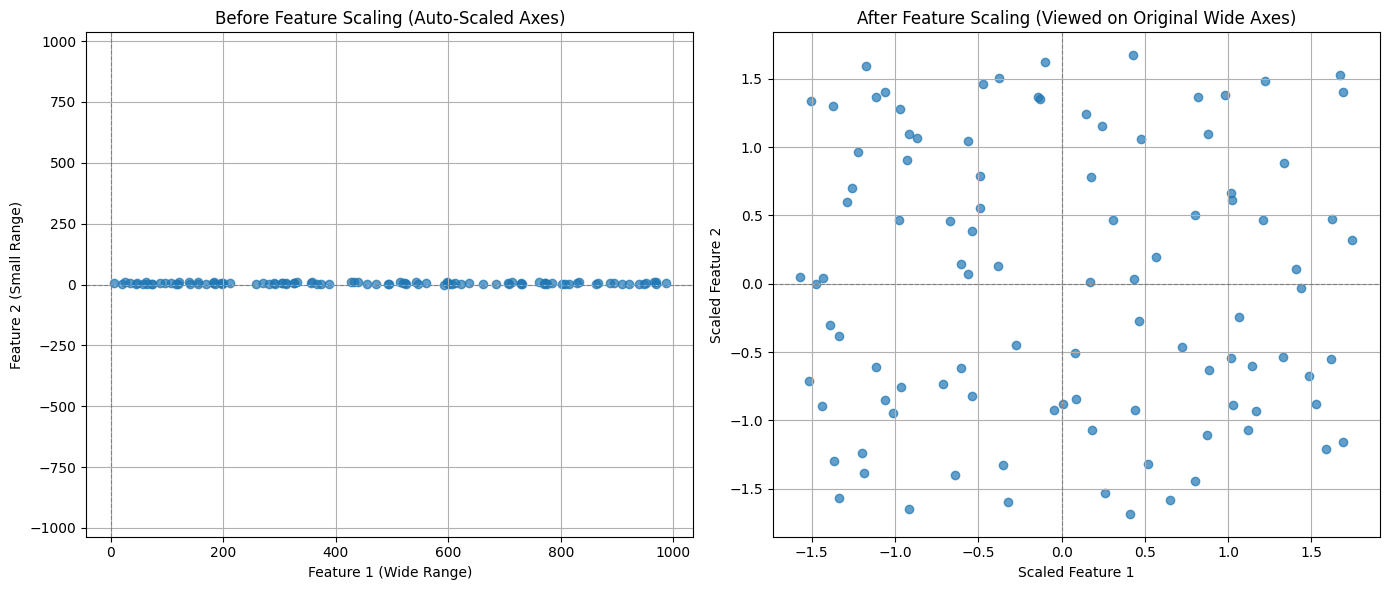

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Create a dataset with two features: one with a wide range, one with a small range
np.random.seed(42) # for reproducibility
X = np.zeros((100, 2))
X[:, 0] = np.random.rand(100) * 1000  # Feature 1: wide range (e.g., 0 to 1000)
X[:, 1] = np.random.rand(100) * 10    # Feature 2: small range (e.g., 0 to 10)

# Calculate original data's min/max for setting fixed axis limits on the scaled plot
x_min_orig, x_max_orig = X[:, 0].min(), X[:, 0].max()
y_min_orig, y_max_orig = X[:, 1].min(), X[:, 1].max()

# Add a small buffer to the limits for better visualization
x_buffer = (x_max_orig - x_min_orig) * 0.05
y_buffer = (y_max_orig - y_min_orig) * 0.05

x_lim_low = x_min_orig - x_buffer
x_lim_high = x_max_orig + x_buffer
y_lim_low = y_min_orig - y_buffer
y_lim_high = y_max_orig + y_buffer

lim_high = max(x_lim_high, y_lim_high)
lim_low = min(x_lim_low, y_lim_low)

# 2. Create the plots
plt.figure(figsize=(14, 6))

# Subplot 1: Data Before Scaling (axes auto-scaled to show data clearly)
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.title('Before Feature Scaling (Auto-Scaled Axes)')
plt.xlabel('Feature 1 (Wide Range)')
plt.ylabel('Feature 2 (Small Range)')
plt.xlim(lim_low, lim_high)
plt.ylim(-lim_high, lim_high)
plt.grid(True)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8) # Add x=0 line
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add y=0 line

# 3. Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Subplot 2: Data After Scaling (axes set to original data's wide limits)
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.7)
plt.title('After Feature Scaling (Viewed on Original Wide Axes)')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.grid(True)
# Apply the original data's wide limits to visualize the compression

plt.axvline(0, color='gray', linestyle='--', linewidth=0.8) # Add x=0 line
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add y=0 line

plt.tight_layout()
plt.show()

## Data Management







Last week, we saw the gradient descent on a simple example. The code looked like this:

```python
for epoch in range(200):
    predictions = perceptron(X_train)
    loss = loss_fn(predictions, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
```

We had 100 points on `X_train` and `Y_train` (inputs and outputs, respectively). As you can see in the code, there is **not** a loop to go through all samples in X_train. What is happening?

- **Running on CPU**: both the model and the data are loaded on the computer's RAM and the predictions are run on it sequentially. One by one.
- **Running on GPU**: both the model and the data are loaded on the GPU's RAM and the predictions run in parallel.

However, how many samples can fit in the RAM memory, together with the model? What would had happened if we had 1,000 points? What about 1,000,000? What if the samples are not simple vectors, but something that weighs more, like images?


### The Mini-batch and batch size



The answer is: **we cannot fit them all**. So we don't.

When we pass the whole training set in one go to the model, that data is technically called *the batch*. Deep learning models are very much data hungry, so it is a natural thing that we cannot fit *the batch* in memory.

That is why we use *the mini-batch*. It is a small subset of samples from our dataset. Instead of passing the entire dataset at once, we pass it in small groups. The code, therefore, now looks like this:

```python
for epoch in range(200):
  for batch in data_loader:
    x, y = batch
    predictions = perceptrons(x)
    loss = loss_fn(predictions, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
```

This implies a fundamental change: **we are updating the weights of the model every time it sees a batch**.

**Important note**: since we cannot fit *the batch* in memory in most cases &mdash; which means we never use *the batch* as terminology because we never refer to it &mdash; and *mini-batch* is a long expression, *the mini-batch* is usually refered to as a *batch*. This might seem confusing, but I want to make it clear now so that the use of the word *batch* from now on refers to *mini-batch*.


When it comes to PyTorch, we have two different classes to manage the data:

- **Dataset**: this class needs two obligatory methods, taking aside the `__init__` one. The first one is `__len__`, which tells us the amount of samples the dataset has, and the second one is `__getitem__(idx)`, which returns the sample at index `idx`.
- **DataLoader**: this is the class that manages what we have just talked about. In the `__init__` method, we pass to it the defined `Dataset` object, and things like the `batch_size`, `shuffle` (boolean to decide if we want to shuffle the data), and other things.

To have a deeper look to them, look at the [PyTorch documentation](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html). We will use them in today's exercises.

## Training Logistics

Last time, we talked a little bit about the loss landscape. Let's properly define it.

### Loss Landscape: what defines it, how do we navigate it and how we can shape it for a better outcome

As we said last week, the loss landscape shape depends on three different things:

- **Training data**: the data we show to the model when training shapes the landscape. That is why it is very important to the a proper pre-processing of the data (cleaning, normalizing, etc.)
- **Architecture of the model**: the weights and parameters and how they are distributed through the network also change this landscape. Chosing the proper model for a problem is important because of that.
- **The Loss Function**: this is the most obvious culprit. How you define the differences between the model's output and the ground truth will make or break your training.

Let's focus on the data this week.

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# 1. Define the Loss Landscape (Quadratic Bowl)
def loss_function(x, y):
    return 0.5 * (x**2 + 10 * y**2)

def gradient(x, y):
    return np.array([x, 10 * y])

# 2. Helper function to perform Gradient Descent variants
def run_gradient_descent(mode='batch', lr=0.1, epochs=50, batch_size=1, data_size=100):
    path = []
    current_pos = np.array([4.0, 4.0]) # Starting point
    path.append(current_pos.copy())

    for epoch in range(epochs):
        if mode == 'batch':
            grad = gradient(current_pos[0], current_pos[1])
            current_pos -= lr * grad
            path.append(current_pos.copy())
        elif mode == 'stochastic':
            # Update for every 'sample' (simulated by adding small noise to the true gradient)
            for _ in range(data_size):
                noise = np.random.normal(0, 5, 2)
                grad = gradient(current_pos[0], current_pos[1]) + noise
                current_pos -= (lr/10) * grad
                path.append(current_pos.copy())
        elif mode == 'minibatch':
            # Update for groups
            num_batches = data_size // batch_size
            for _ in range(num_batches):
                noise = np.random.normal(0, 2, 2)
                grad = gradient(current_pos[0], current_pos[1]) + noise
                current_pos -= lr * grad
                path.append(current_pos.copy())

    return np.array(path)

# 3. Setup Plotting Environment
def plot_landscape(path, title):
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x, y)
    Z = loss_function(X, Y)

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, Z, levels=20, cmap='viridis')
    plt.plot(path[:, 0], path[:, 1], '-o', color='red', markersize=2, label='Path')
    plt.plot(path[0, 0], path[0, 1], 'go', label='Start')
    plt.plot(0, 0, 'rx', label='Minimum')
    plt.title(title)
    plt.xlabel('Parameter w1')
    plt.ylabel('Parameter w2')
    plt.legend()
    plt.show()

Let's suppose we have a perfectly convex loss landscape. It is easy to find the global minima; we just need to go down the slope.

As we said before, this landscape is defined by the training data. All of it.

In this hypothetical case, if we did a *batch* gradient descent &mdash; we pass all training data to the model at once and we get a global loss value for all training data &mdash; we would go, step by step, in the correct direction.

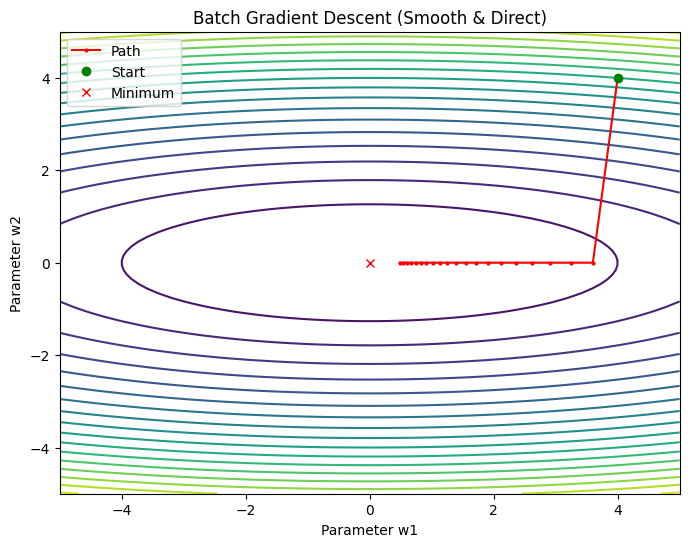

In [ ]:
# @title
# Batch Gradient Descent: Uses the whole dataset for one update
batch_path = run_gradient_descent(mode='batch', lr=0.1, epochs=20)
plot_landscape(batch_path, 'Batch Gradient Descent (Smooth & Direct)')

What happens when we do a *mini-batch* gradient descent?

The model is not seeing the whole picture. In fact, we have a different loss landscape for every *mini-batch* that the model sees. We are updating the weights given a smaller sample of the whole training data.

That makes the descent noisier, since, when considering the whole loss landscape, we are not always going down. However, once the model has seen all batches, the mean descent vector tends to be in the desired direction.

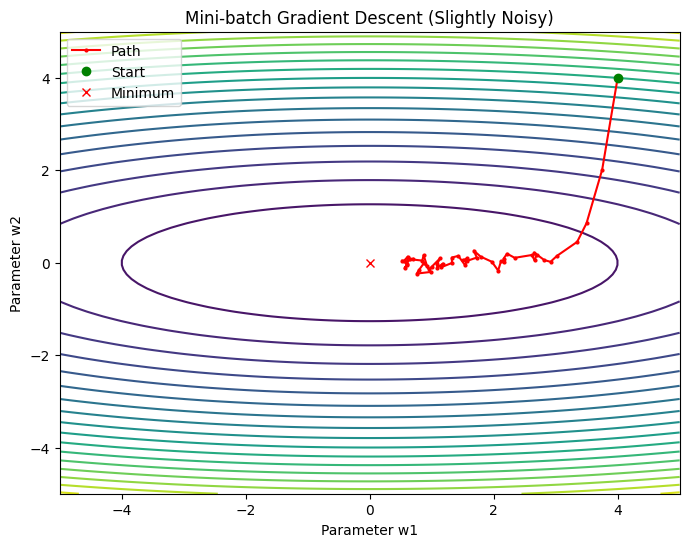

In [ ]:
# @title
# Mini-batch Gradient Descent: Uses subsets of data
minibatch_path = run_gradient_descent(mode='minibatch', lr=0.05, epochs=5, batch_size=10)
plot_landscape(minibatch_path, 'Mini-batch Gradient Descent (Slightly Noisy)')

There are other types of descent, like the Stochastic Gradient Descent, were one sample is seen by the model at a time. Of course, this makes the path even worse, but it always tends to be in the desired direction.

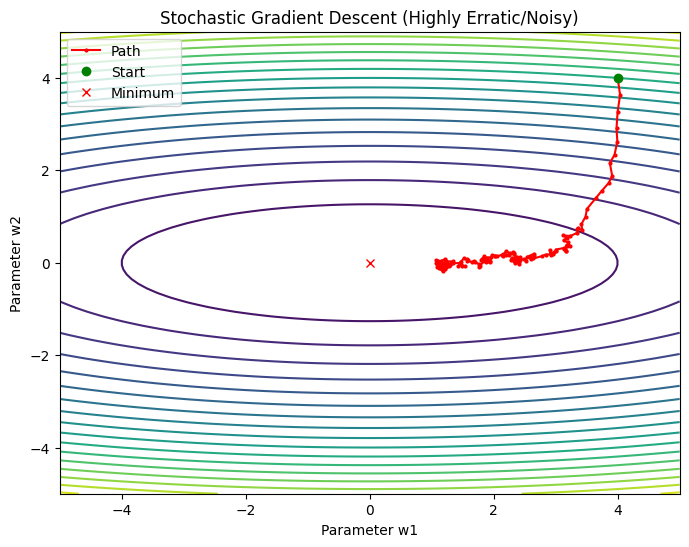

In [ ]:
# @title
# Stochastic Gradient Descent: Updates after every single sample
sgd_path = run_gradient_descent(mode='stochastic', lr=0.1, epochs=1, data_size=150)
plot_landscape(sgd_path, 'Stochastic Gradient Descent (Highly Erratic/Noisy)')

Ok. We cannot have the perfect path because we cannot fit all data at once in RAM. Passing the data in mini-batches makes the path noisier.

Can we change, somehow, how we move in this space?

#### Optimizers

Optimizers are the algorithms that make us move through the landscape. The gradient descent algorithm that we saw last week:

$$w_{i+1} = w_i - \eta\nabla L(w_i) $$

Is an optimizer algorithm.

Again, the partial derivative is now defined by the mini-batch. We are not going to always go to the global minimum with this algorithm.

But there are others.

##### Stochastic Gradient Descent (SGD) with Momentum

$$v_{i+1} = \alpha v_i - \eta \nabla L(w_i)$$

$$w_{i+1} = w_i + v_{i+1}$$

With SGD with Momentum, we are treating the weights as a particle with mass and velocity. The $v$ term would be the velocity vectors, which have a certain direction, and the $w$ terms would be our position. Therefore, $\alpha v_i$ is our momentum, which carries a percentage ($\alpha$) of the previous direction.

##### Adaptive Gradient Descent (AdaGrad)

The whole concept behind this algorithm is to adjust the learning rate parameter to every weight depending on how disperse they are during training. For that, we track the history of our gradients:

$$s_i = s_{i-1} + (\nabla L(w_i))^2$$

And we update the weights with an adapted learning rate:

$$w_{i+1} = w_i - \frac{\eta}{\sqrt{s_i + \epsilon}} \nabla L(w_i)$$

##### Root Mean Square Propagation (RMSProp)

Just as in Adagrad, the learning rate is adapted to each parameter. In this case, we avoid the ever increasing sum (it makes the learning rate to tend fast to 0), and we introduce weight decay:

$$s_i = \gamma s_{i-1} + (1 - \gamma)(\nabla L(w_i))^2 $$

It is a moving average. If we want to look at more recent gradients, we increase the $\gamma$ value.

##### Adaptive Moment Estimation (Adam)

Adam combines the concepts introduced by Momentum and RMSProp. The exponential forgetting happens with both the gradients and the second moment of gradients. We introduce two new hyperparameters that take the role of the previous $\gamma$: $\beta_1$ and $\beta_2$.

$$m_i = \beta_1 m_{i-1} + (1 - \beta_1) \nabla L(w_i)$$

$$v_i = \beta_2 v_{i-1} + (1 - \beta_2) (\nabla L(w_i))^2$$

Both $m$ and $v$ are initialized at zero, so they tend to it in the initial steps. We correct them as:

$$\hat{m}_i = \frac{m_i}{1 - \beta^i_1}$$

$$\hat{v}_i = \frac{v_i}{1 - \beta^i_2}$$

And then:

$$w_{i+1} = w_i - \eta \frac{\hat{m}_i}{\sqrt{\hat{v}_i} + \epsilon}$$


### Training curves

**Epoch**: one complete pass of the entire training dataset through the model. One epoch is finished when all mini-batches in the training set have passed through the model.

**Training curves**: graphical representation that shows how a model's performance changes during training with the number of *epochs* or *mini-batches*. We use them to see how the model is learning; they represent the evolution of the *loss* and some other *metrics* that we can define.

In [2]:
from IPython.display import Image, display

url = "https://huggingface.co/datasets/huggingface-course/documentation-images/resolve/main/en/chapter3/5.png"
display(Image(url=url, width=1000))

These are healthy learning curves. They display:
- **Decrease / Increase**: we see a decrease / increase that shows the model is learning.
- **Convergence**: the loss plateaus at a certain point for both training and validation sets.
- **Small gap**: there is a gap between the two curves, showing that the model performs better on the samples it has seen during training.

How do they look when the training is not going well? What might be happening?

#### Overfiting

In [4]:
from IPython.display import Image, display

url = "https://huggingface.co/datasets/huggingface-course/documentation-images/resolve/main/en/chapter3/10.png"
display(Image(url=url, width=500))

Overfitting occurs when the model learns too much from the training data &mdash; it memorizes it &mdash; and it is unable to generalize to the data it has not seen in the validation set. We can identify overfitting when **training loss continues to decrease while validation loss increases or plateaus** and when **the gap between the two is considerable**.

#### Underfitting

In [5]:
from IPython.display import Image, display

url = "https://huggingface.co/datasets/huggingface-course/documentation-images/resolve/main/en/chapter3/7.png"
display(Image(url=url, width=500))

Underfitting happens when the model is incapable of learning. This can happen for several reasons:
- Learning rate is too small, and the model is learning very slowly.
- The dataset is too small; the model is not seeing enough examples to understand the underlying patterns of the data.
- The model is too small; the amount of parameters or the architecture of it are not enough for it to learn.


To identify it, we can see that both losses remain high (in the picture is not depicted) and that model performance plateaus early.

#### Erratic curves

In [6]:
from IPython.display import Image, display

url = "https://huggingface.co/datasets/huggingface-course/documentation-images/resolve/main/en/chapter3/3.png"
display(Image(url=url, width=500))

It can happen in both the validation and training curves. It can happen because:
- Learning rate is too high; we are jumping out of local minima.
- Batch size is too small, making the gradients unstable.
- Lack of regularization of the model. This can mean a lot of things, but one of the common ones are **exploding gradients**: the weights of the model are becoming too big, therefore the gradients are too big, and the changes performed to each weight after each iteration make them jump out from local minima.
- Data is not regularized and the model is learning from the noise in there.

To identify it, we can see jumps up and down on the validation curve or on both curves.

The images where extracted from this [LLM curse's chapter](https://huggingface.co/learn/llm-course/chapter3/5), which explains these aspects of training very well. Check it out!

### Regularization techinques

These are methods to prevent things like overfitting and exploding gradients during our training.
- **Dropout**: randomly deactivate a fraction of neurons during training.
- **L2 / L1 Regularization**: we add an extra term to the loss to incentivize the weights for a lower value:
$$L_{L_1} = L_{original} + \lambda \sum |w|$$
$$L_{L_2} = L_{original} + \lambda \sum w^2$$
- **Early stopping**: when the validation metrics start to degrade, we stop training.
- **Data augmentation**: artificially increase the amount of data seen by the model by adding small noise to the inputs.
- **Batch regularization**: normalize inputs to each layer to improve stability throughout all the network.

And more that we will see next week when we look at different network architectures.

## Extra: Explainable AI

Two concepts:
- **Interpretability**: it focuses on how a model operates, buitl-in from the start. It refers to the degree a human can understand the underlying mechanics and decision logic of an AI model.
- **Explainability**: focuses on explaining the why behind the decision for "black box" models that are not naturally interpretable.

Explainable AI is a set of tools and methods that allow us to understand better what is happening inside the "black box" that deep learning models are. When we are facing delicate problems, where the outputs of a model can affect people directly, it is important to understand why the model is making certain predictions, why it fails and under what conditions.

Explainable AI helps with things such as:

- **Fairness**: helps detecting the biases that might have been ingrained in the model during training. The biases that might exist in the training data will always be reflected by the model.
- **Trust and reliability**: we need them when it comes to high-stakes industries, such as health-care or banking.





### Local Interpretable Model-Agnositc Explanations (LIME)

LIME is a technique that we use to approximate the model's decision making with a local, interpretable model to explain each individual prediction. Here's the [paper](https://arxiv.org/pdf/1602.04938).

As the name suggests, it is a model-agnostic method, meaning we can apply it to any problem, with any type of data. The process is as follows:

1. Select a sample and perturb it, creating slightly modified versions of it.
2. Get predictions for these new samples.
3. Weigh the new data points as a function to their proximity to the original point.
4. Fit a simple, interpretable model (e.g., linear regression) on the weighted samples.

Each original data point can then be explained with the newly trained explanation.

In [8]:
# @title
from IPython.display import Image, display

url = "https://christophm.github.io/interpretable-ml-book/lime_files/figure-html/fig-lime-fitting-1.png"
display(Image(url=url, width=700))

### SHapley Additive exPlanations (SHAP)




"SHAP assigns each feature an importance value for a particular prediction". [*Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. Advances in neural information processing systems, 30.*](https://arxiv.org/pdf/1705.07874)


In [9]:
from IPython.display import Image, display

url = "https://shap.readthedocs.io/en/latest/_images/shap_header.png"
display(Image(url=url, width=700))

SHAP explains the prediction on each instance by calculating how each feature of the input contributes to the output. Those values are calculated with Shapley values, e.g. game theory.

### Gradient-weighted Class Activation Mapping (Grad-CAM)



This method is exclusive for image classifiers. It generates heat-maps in the input image to visualize what part of the image was more influential in the model's final decision.

In [10]:
from IPython.display import Image, display

url = "https://liora.io/app/uploads/sites/7/2021/07/Original-Image.jpg"
display(Image(url=url, width=700))

Basically, it looks at the gradients of the last convolutional layer given one of the classification decisions. Follows the gradients back and looks at their sensitivity/activations in that last layers.